# Importing Libraries

In [323]:
# Data_manipulation
import pandas as pd
# Numerical_computing
import numpy as np
# Data_visualization
import matplotlib.pyplot as plt
# Statistical_data_visualization
import seaborn as sns
# Machine_learning_toolkits
# Random_Forest_regressor_from_Scikit-learn
from sklearn.ensemble import RandomForestRegressor
# Metrics_for_model_evaluation
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, mean_absolute_error
# For_splitting_dataset_and grid_search
from sklearn.model_selection import train_test_split, GridSearchCV
# Support_Vector_Regressor_and_Classifier_from_Scikit-learn
from sklearn.svm import SVR, SVC
# For_standardizing_features And For_encoding_categorical_variables
from sklearn.preprocessing import StandardScaler, LabelEncoder
# For_imputing_missing_values
from sklearn.impute import SimpleImputer
# Gradient_boosting_framework
import lightgbm as lgb
# Deep_learning_framework
import tensorflow as tf
# Geographic_data_analysis
import geopandas as gpd
#Squarify_for_treemap_visualization
import squarify as sq

# Loading Dataset(Electric Vehicle Population)

In [324]:
#Exploring_data_file
evp_data = pd.read_csv('Electric_Vehicle_Population_Data.csv')

In [325]:
#defining_head_of_dataSet
evp_data.head()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,5YJYGDEE1L,King,Seattle,WA,98122.0,2020,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,291,0,37.0,125701579,POINT (-122.30839 47.610365),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
1,7SAYGDEE9P,Snohomish,Bothell,WA,98021.0,2023,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,1.0,244285107,POINT (-122.179458 47.802589),PUGET SOUND ENERGY INC,5.306105e+10
2,5YJSA1E4XK,King,Seattle,WA,98109.0,2019,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,270,0,36.0,156773144,POINT (-122.34848 47.632405),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
3,5YJSA1E27G,King,Issaquah,WA,98027.0,2016,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,210,0,5.0,165103011,POINT (-122.03646 47.534065),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
4,5YJYGDEE5M,Kitsap,Suquamish,WA,98392.0,2021,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,23.0,205138552,POINT (-122.55717 47.733415),PUGET SOUND ENERGY INC,5.303594e+10


In [326]:
#defining_tail_of_dataSet
evp_data.tail()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
177861,7SAYGDEE3N,Pierce,Bonney Lake,WA,98391.0,2022,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,31.0,195224452,POINT (-122.183805 47.18062),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.305307e+10
177862,KM8K23AG1P,Mason,Shelton,WA,98584.0,2023,HYUNDAI,KONA ELECTRIC,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,35.0,228454180,POINT (-123.105305 47.211085),BONNEVILLE POWER ADMINISTRATION||CITY OF TACOM...,5.304596e+10
177863,5YJYGDEE6M,Grant,Quincy,WA,98848.0,2021,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,13.0,168797219,POINT (-119.8493873 47.2339933),PUD NO 2 OF GRANT COUNTY,5.302501e+10
177864,WVGKMPE27M,King,Black Diamond,WA,98010.0,2021,VOLKSWAGEN,ID.4,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,5.0,182448801,POINT (-122.00451 47.312185),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
177865,5YJ3E1EA8M,Pierce,Tacoma,WA,98422.0,2021,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,27.0,211464683,POINT (-122.38578 47.28971),BONNEVILLE POWER ADMINISTRATION||CITY OF TACOM...,5.305394e+10


In [327]:
#check_columns
print(evp_data.columns)

Index(['VIN (1-10)', 'County', 'City', 'State', 'Postal Code', 'Model Year',
       'Make', 'Model', 'Electric Vehicle Type',
       'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Range',
       'Base MSRP', 'Legislative District', 'DOL Vehicle ID',
       'Vehicle Location', 'Electric Utility', '2020 Census Tract'],
      dtype='object')


# Summary of dataset(Electric Vehicle Population)

In [328]:
#Discription_house_prediction_dataset
print(evp_data.describe())


         Postal Code     Model Year  Electric Range      Base MSRP  \
count  177861.000000  177866.000000   177866.000000  177866.000000   
mean    98172.453506    2020.515512       58.842162    1073.109363   
std      2442.450668       2.989384       91.981298    8358.624956   
min      1545.000000    1997.000000        0.000000       0.000000   
25%     98052.000000    2019.000000        0.000000       0.000000   
50%     98122.000000    2022.000000        0.000000       0.000000   
75%     98370.000000    2023.000000       75.000000       0.000000   
max     99577.000000    2024.000000      337.000000  845000.000000   

       Legislative District  DOL Vehicle ID  2020 Census Tract  
count         177477.000000    1.778660e+05       1.778610e+05  
mean              29.127481    2.202313e+08       5.297672e+10  
std               14.892169    7.584987e+07       1.578047e+09  
min                1.000000    4.385000e+03       1.001020e+09  
25%               18.000000    1.814743e+08 

# Number of rows selected for modelling

In [329]:
#sampling
evp_data_sample = evp_data.sample(n=25000, random_state=42)

# DataSet Information

In [330]:
#Information_of_dataSet
evp_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 177866 entries, 0 to 177865
Data columns (total 17 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         177866 non-null  object 
 1   County                                             177861 non-null  object 
 2   City                                               177861 non-null  object 
 3   State                                              177866 non-null  object 
 4   Postal Code                                        177861 non-null  float64
 5   Model Year                                         177866 non-null  int64  
 6   Make                                               177866 non-null  object 
 7   Model                                              177866 non-null  object 
 8   Electric Vehicle Type                              177866 non-null  object

# DATASET_SHAPE

In [331]:
# Check_the_shape_of_the_original_dataset
print("Actual dataset Shape:", evp_data.shape)
# Check_the_shape_of_the_reduced_dataset
print("Reduced dataset shape:", evp_data_sample.shape)


Actual dataset Shape: (177866, 17)
Reduced dataset shape: (25000, 17)


# Data Cleaning
#### 1.Removing Unnecessary Columns
#### 2.Checking Null values
#### 3.Removing Duplicates
#### 4.Label Encoding
#### 5. Removing White Spaces

In [332]:
#droping_not_required_or_useful_columns 
evp_data_sample.drop(['DOL Vehicle ID','Vehicle Location','2020 Census Tract', 'VIN (1-10)', 'County', 'Legislative District','Postal Code'], axis=1, inplace=True)

In [333]:
print(evp_data_sample.head())

              City State  Model Year   Make    Model  \
107346     Seattle    WA        2019  TESLA  MODEL 3   
161638  Bellingham    WA        2016  SMART   FORTWO   
75814     Kirkland    WA        2023  TESLA  MODEL S   
102108    Gold Bar    WA        2022  TESLA  MODEL 3   
152786    Mukilteo    WA        2023  TESLA  MODEL Y   

                 Electric Vehicle Type  \
107346  Battery Electric Vehicle (BEV)   
161638  Battery Electric Vehicle (BEV)   
75814   Battery Electric Vehicle (BEV)   
102108  Battery Electric Vehicle (BEV)   
152786  Battery Electric Vehicle (BEV)   

        Clean Alternative Fuel Vehicle (CAFV) Eligibility  Electric Range  \
107346            Clean Alternative Fuel Vehicle Eligible             220   
161638            Clean Alternative Fuel Vehicle Eligible              68   
75814   Eligibility unknown as battery range has not b...               0   
102108  Eligibility unknown as battery range has not b...               0   
152786  Eligibility unkno

In [334]:
#check_"Null_Values"_in_dataset
evp_data_sample.isnull().sum()

City                                                 0
State                                                0
Model Year                                           0
Make                                                 0
Model                                                0
Electric Vehicle Type                                0
Clean Alternative Fuel Vehicle (CAFV) Eligibility    0
Electric Range                                       0
Base MSRP                                            0
Electric Utility                                     0
dtype: int64

# Dropping Duplicate Rows

In [335]:
# Number_of_repeated_rows
repeated_rows = evp_data_sample[evp_data_sample.duplicated()]
print(f'Number of repeated rows: {len(repeated_rows)}')
# Droping_repeated_rows
evp_data_sample = evp_data_sample.drop_duplicates()

Number of repeated rows: 14718


In [336]:
evp_data_sample.shape

(10282, 10)

In [337]:
evp_data_sample1=evp_data_sample.copy()

# Label Encoding
#### Converting Categoral Data to Numeric form

In [338]:
# Convert_String_into_numerics
columns_to_encode = ['Make','Model', 'Electric Vehicle Type', 'Electric Utility', 'Clean Alternative Fuel Vehicle (CAFV) Eligibility','City', 'State']

# apply_LabelEncoder
L_E = LabelEncoder()

# Apply_label_encoding_to_each_column_and_drop_the original_columns
for col in columns_to_encode:
    if col in evp_data_sample1.columns:
        evp_data_sample1[col + '_encoded'] = L_E.fit_transform(evp_data_sample1[col])
        evp_data_sample1.drop(col, axis=1, inplace=True)
    else:
        print(f"Column '{col}' not found in the DataFrame.")

print(evp_data_sample1.head())

        Model Year  Electric Range  Base MSRP  Make_encoded  Model_encoded  \
107346        2019             220          0            31             72   
161638        2016              68          0            29             43   
75814         2023               0          0            31             73   
102108        2022               0          0            31             72   
152786        2023               0          0            31             75   

        Electric Vehicle Type_encoded  Electric Utility_encoded  \
107346                              0                        47   
161638                              0                        64   
75814                               0                        63   
102108                              0                        26   
152786                              0                        62   

        Clean Alternative Fuel Vehicle (CAFV) Eligibility_encoded  \
107346                                                  0  

# Checking White-Spaces

In [339]:
# Check_for_whitespace_in_feature_names
whitespace_columns = [col for col in evp_data_sample1.columns if '-' in col]

# Display_columns_with_whitespace
if whitespace_columns:
    print("Columns with '-' found:")
    for col in whitespace_columns:
        print(col)
else:
    print("No columns with '-' found.")


No columns with '-' found.


In [340]:
evp_data_sample1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10282 entries, 107346 to 173660
Data columns (total 10 columns):
 #   Column                                                     Non-Null Count  Dtype
---  ------                                                     --------------  -----
 0   Model Year                                                 10282 non-null  int64
 1   Electric Range                                             10282 non-null  int64
 2   Base MSRP                                                  10282 non-null  int64
 3   Make_encoded                                               10282 non-null  int32
 4   Model_encoded                                              10282 non-null  int32
 5   Electric Vehicle Type_encoded                              10282 non-null  int32
 6   Electric Utility_encoded                                   10282 non-null  int32
 7   Clean Alternative Fuel Vehicle (CAFV) Eligibility_encoded  10282 non-null  int32
 8   City_encoded             

In [341]:
print(evp_data_sample1.columns)

Index(['Model Year', 'Electric Range', 'Base MSRP', 'Make_encoded',
       'Model_encoded', 'Electric Vehicle Type_encoded',
       'Electric Utility_encoded',
       'Clean Alternative Fuel Vehicle (CAFV) Eligibility_encoded',
       'City_encoded', 'State_encoded'],
      dtype='object')


# Visualization

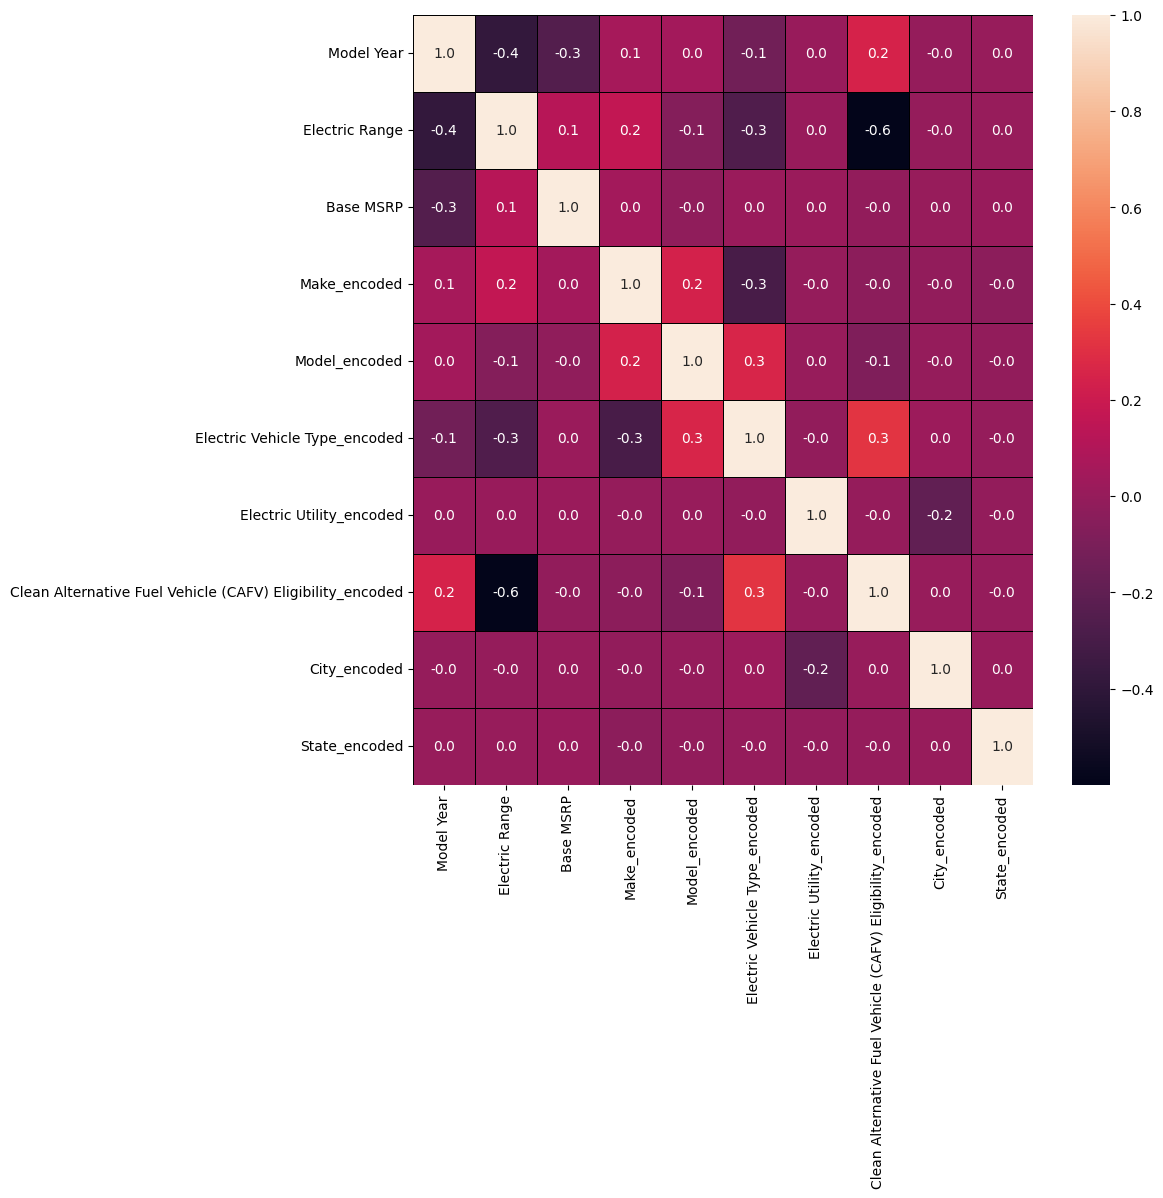

In [342]:
#heatmap
f,ax=plt.subplots(figsize=(10,10))
sns.heatmap(evp_data_sample1.corr(),annot=True,linewidths=0.5,linecolor="black",fmt=".1f",ax=ax)
plt.show()

array([[<Axes: title={'center': 'Model Year'}>,
        <Axes: title={'center': 'Electric Range'}>,
        <Axes: title={'center': 'Base MSRP'}>],
       [<Axes: title={'center': 'Make_encoded'}>,
        <Axes: title={'center': 'Model_encoded'}>,
        <Axes: title={'center': 'Electric Vehicle Type_encoded'}>],
       [<Axes: title={'center': 'Electric Utility_encoded'}>,
        <Axes: title={'center': 'Clean Alternative Fuel Vehicle (CAFV) Eligibility_encoded'}>,
        <Axes: title={'center': 'City_encoded'}>],
       [<Axes: title={'center': 'State_encoded'}>, <Axes: >, <Axes: >]],
      dtype=object)

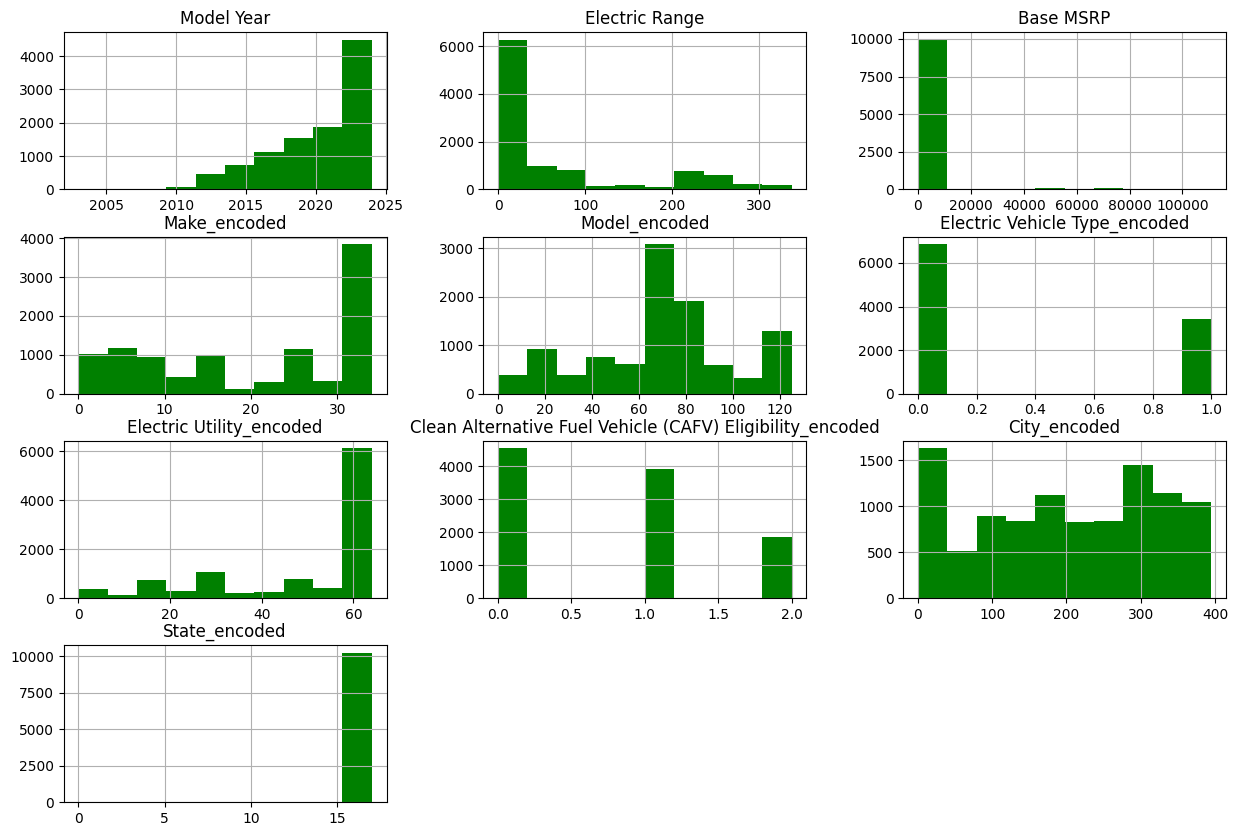

In [343]:
#plotting_a_histogram_of_desired_columns
evp_data_sample1.hist(figsize=(15, 10), color='green') 

In [344]:
#Implementation_of_log_skewed_data
evp_data_sample1["Base MSRP"] = np.log(evp_data_sample1["Base MSRP"] + 1)


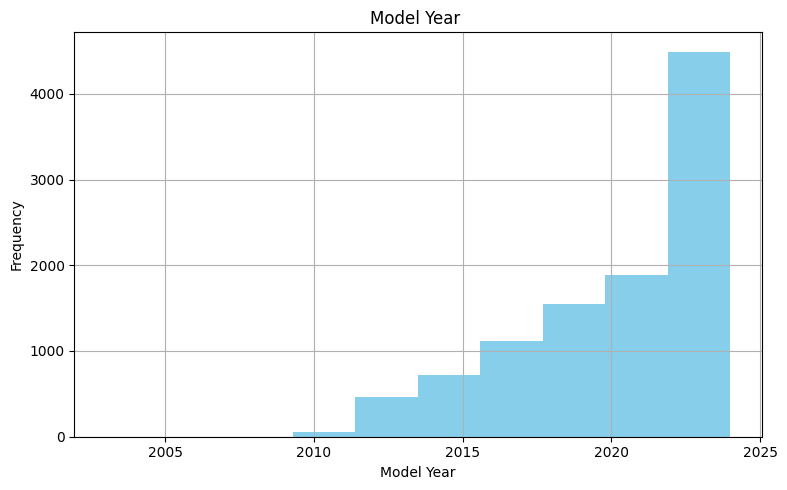

In [345]:
# histogram
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
evp_data_sample1['Model Year'].hist(color='skyblue')
plt.title('Model Year ')
plt.xlabel('Model Year')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

C:\Users\MIne\AppData\Local\Temp\ipykernel_8964\775064466.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(electric_range_data, color='green', shade=True)


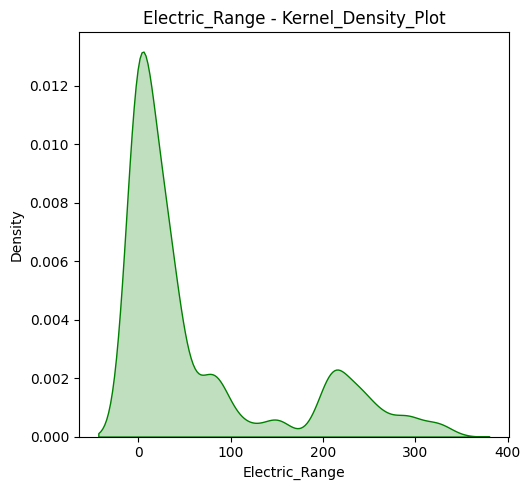

In [346]:
# Filter_out_null_or_empty_values
electric_range_data = evp_data_sample1['Electric Range'].dropna()

# histogram
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 3)
sns.kdeplot(electric_range_data, color='green', shade=True)
plt.title('Electric_Range - Kernel_Density_Plot')
plt.xlabel('Electric_Range')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

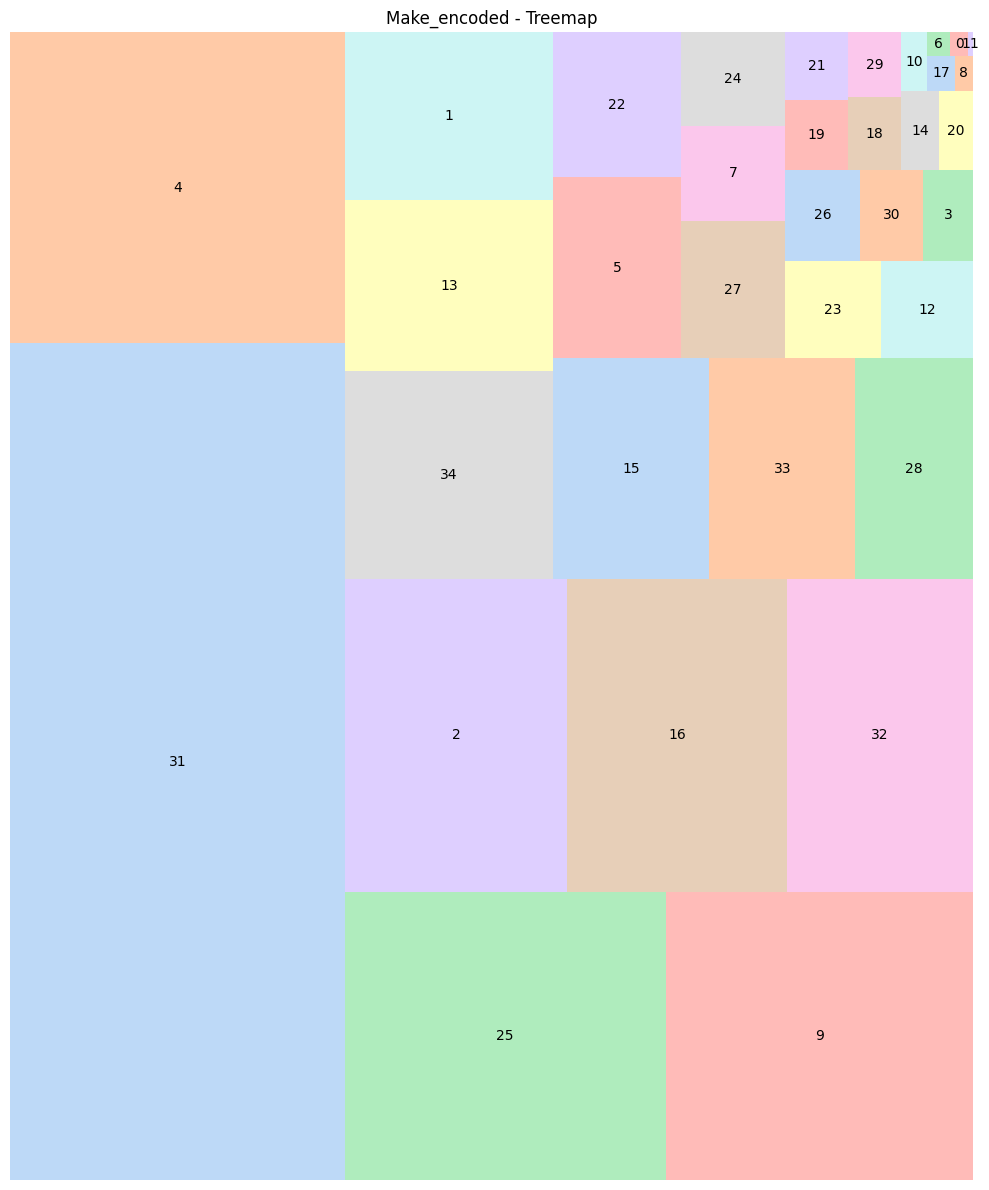

In [347]:
# treemap
plt.figure(figsize=(10, 12))
make_counts = evp_data_sample1['Make_encoded'].value_counts()
sq.plot(sizes=make_counts, label=make_counts.index, color=sns.color_palette('pastel'), alpha=0.7)
plt.axis('off')
plt.title('Make_encoded - Treemap')

plt.tight_layout()
plt.show()


C:\Users\MIne\AppData\Local\Temp\ipykernel_8964\1999138394.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Electric Vehicle Type_encoded', data=evp_data_sample1, palette='husl')


Text(0, 0.5, 'count')

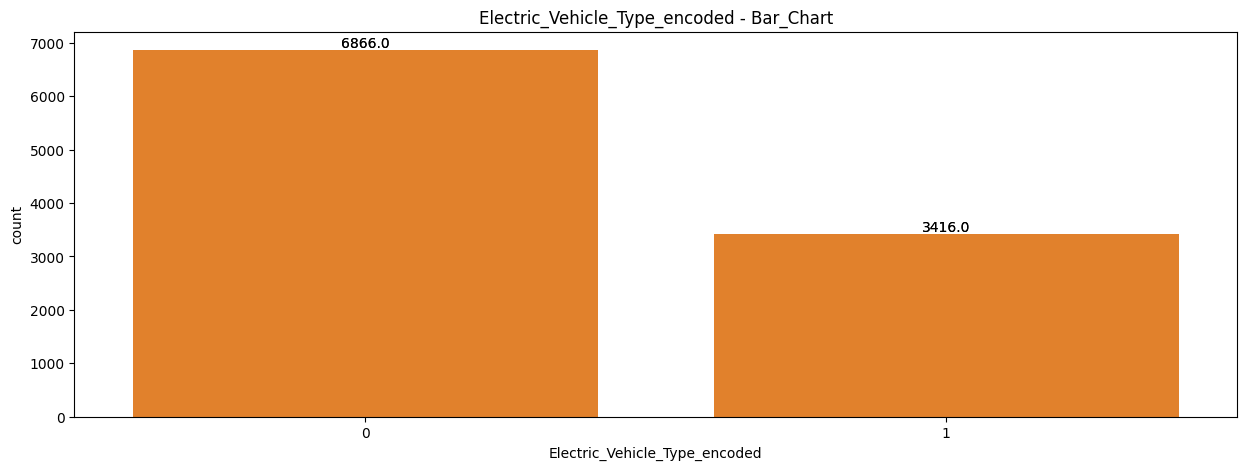

In [348]:
# Bar_chart
plt.figure(figsize=(15, 5))
# plt.subplot(1, 1, 1)
sns.countplot(x='Electric Vehicle Type_encoded', data=evp_data_sample1, palette='husl')
ax = sns.countplot(data=evp_data_sample1, x='Electric Vehicle Type_encoded')

for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')

plt.title('Electric_Vehicle_Type_encoded - Bar_Chart')
plt.xlabel('Electric_Vehicle_Type_encoded')
plt.ylabel('count')

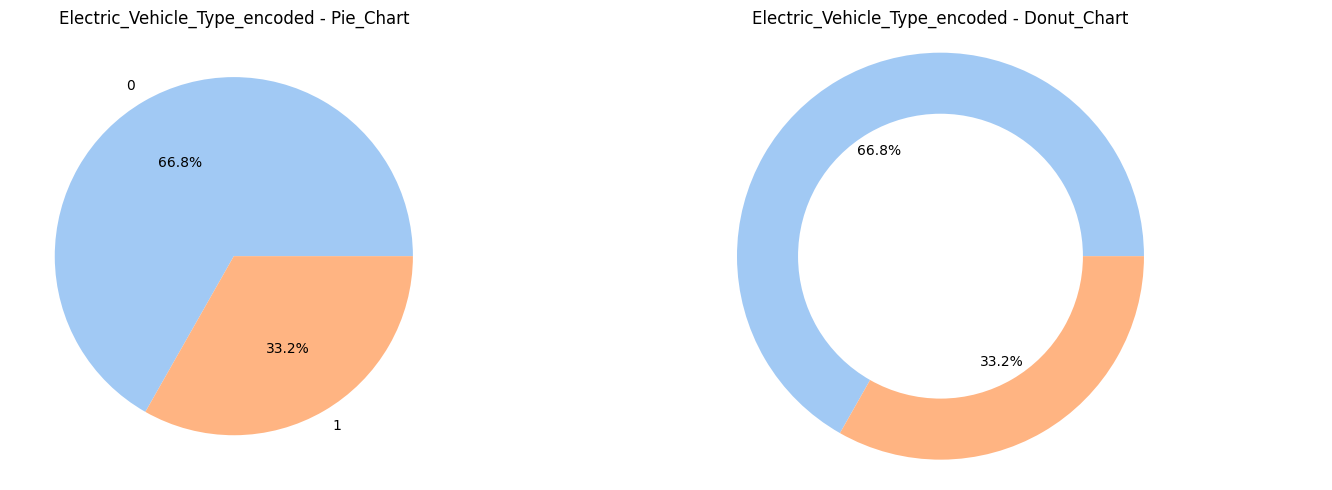

In [349]:
plt.figure(figsize=(15, 5))

# Pie_chart
electric_vehicle_counts = evp_data_sample1['Electric Vehicle Type_encoded'].value_counts()
plt.subplot(1, 2, 1)
plt.pie(electric_vehicle_counts, labels=electric_vehicle_counts.index, autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title('Electric_Vehicle_Type_encoded - Pie_Chart')

# Donut_chart
plt.subplot(1, 2, 2)
plt.pie(electric_vehicle_counts, labels=None, autopct='%1.1f%%', colors=sns.color_palette('pastel'), wedgeprops=dict(width=0.3))
plt.title('Electric_Vehicle_Type_encoded - Donut_Chart')

plt.axis('equal')
plt.tight_layout()
plt.show()


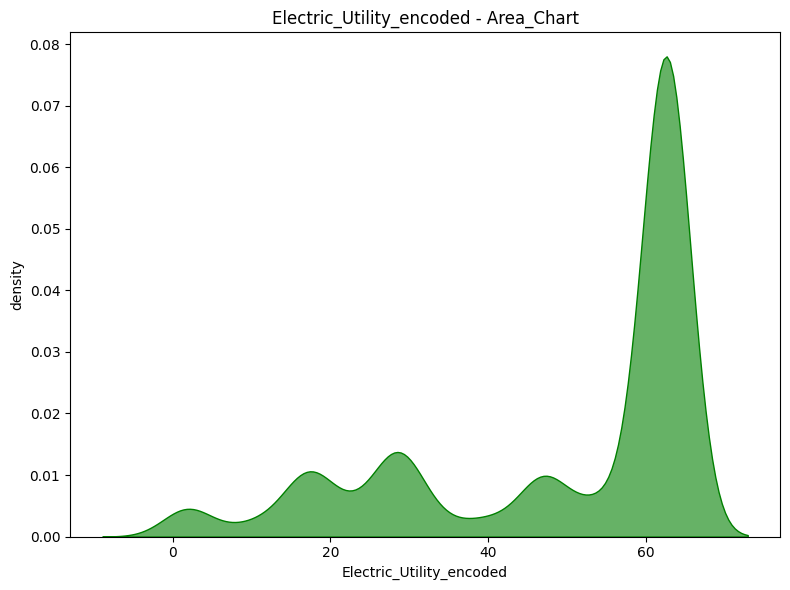

In [350]:
# Area_chart
plt.figure(figsize=(8, 6))
sns.kdeplot(data=evp_data_sample1, x='Electric Utility_encoded', fill=True, color='green', alpha=0.6)
plt.title('Electric_Utility_encoded - Area_Chart')
plt.xlabel('Electric_Utility_encoded')
plt.ylabel('density')

plt.tight_layout()
plt.show()


C:\Users\MIne\AppData\Local\Temp\ipykernel_8964\2609894948.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Clean Alternative Fuel Vehicle (CAFV) Eligibility_encoded', data=evp_data_sample1, palette='husl')


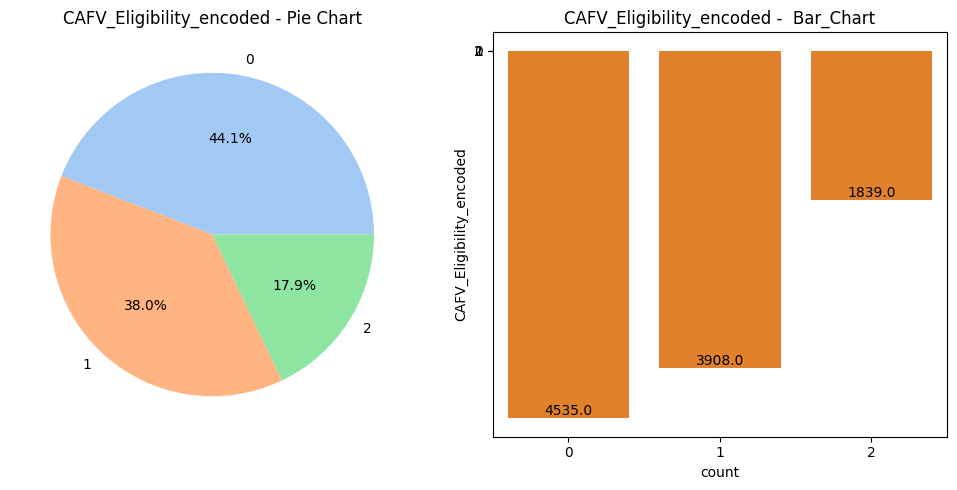

In [351]:
#figure_size
plt.figure(figsize=(15, 5))

# Pie_chart
cafv_eligibility_counts = evp_data_sample1['Clean Alternative Fuel Vehicle (CAFV) Eligibility_encoded'].value_counts()
plt.subplot(1, 3, 2)
plt.pie(cafv_eligibility_counts, labels=cafv_eligibility_counts.index, autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title('CAFV_Eligibility_encoded - Pie Chart')

# Horizontal_bar_chart
plt.subplot(1, 3, 3)
sns.countplot(y='Clean Alternative Fuel Vehicle (CAFV) Eligibility_encoded', data=evp_data_sample1, palette='husl')
ax = sns.countplot(data=evp_data_sample1, x='Clean Alternative Fuel Vehicle (CAFV) Eligibility_encoded')

for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')

plt.title('CAFV_Eligibility_encoded -  Bar_Chart')
plt.xlabel('count')
plt.ylabel('CAFV_Eligibility_encoded')
plt.tight_layout()
plt.show()

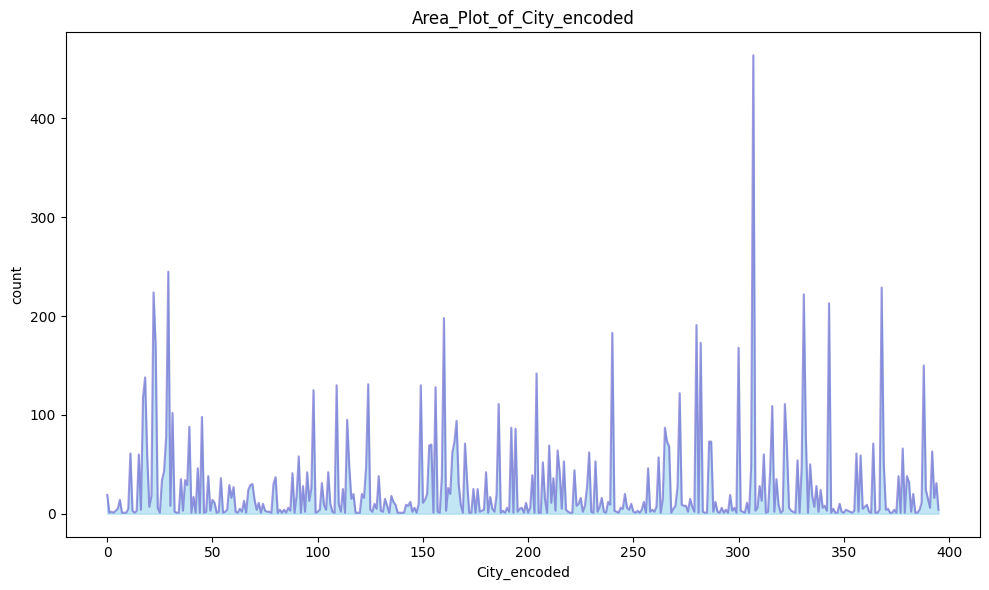

In [352]:
# Count_the_occurrences_of_each_unique_City_encoded_value
city_counts = evp_data_sample1['City_encoded'].value_counts()
city_counts = city_counts.sort_index()

plt.figure(figsize=(10, 6))
plt.fill_between(city_counts.index, city_counts.values, color='skyblue', alpha=0.5)
plt.plot(city_counts.index, city_counts.values, color='Slateblue', alpha=0.6)
plt.title('Area_Plot_of_City_encoded')
plt.xlabel('City_encoded')
plt.ylabel('count')
plt.tight_layout()
plt.show()


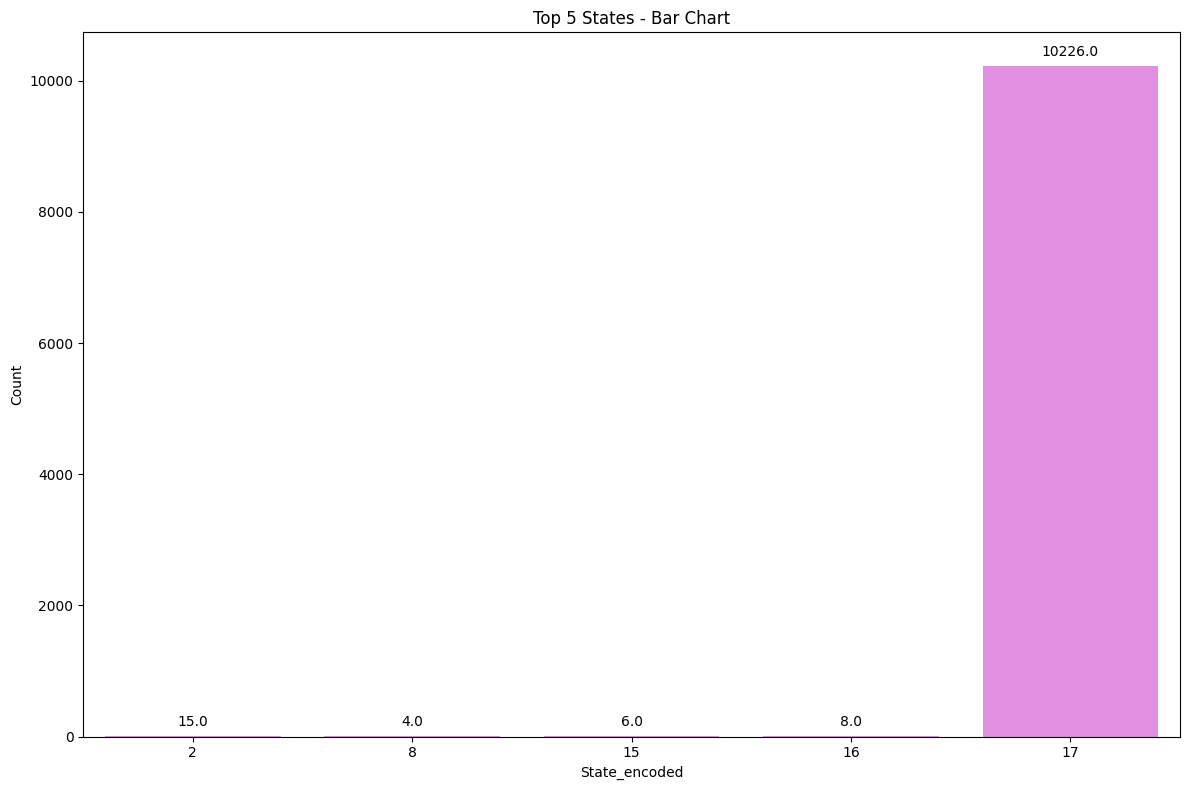

In [353]:
top_5_states = evp_data_sample1['State_encoded'].value_counts().nlargest(5).index

# Filter the DataFrame to include only the top 5 states
evp_data_top_5 = evp_data_sample1[evp_data_sample1['State_encoded'].isin(top_5_states)]

# Plot the bar chart for the top 5 states
plt.figure(figsize=(12, 8))
ax = sns.countplot(x='State_encoded', data=evp_data_top_5, color='violet')
plt.title('Top 5 States - Bar Chart')
plt.xlabel('State_encoded')
plt.ylabel('Count')

# Add counts above the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.tight_layout()
plt.show()

C:\Users\MIne\AppData\Local\Temp\ipykernel_8964\3991960327.py:5: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


(-198.0, 198.00000000000006, -98.6822565, 92.3273865)

<Figure size 1500x1000 with 0 Axes>

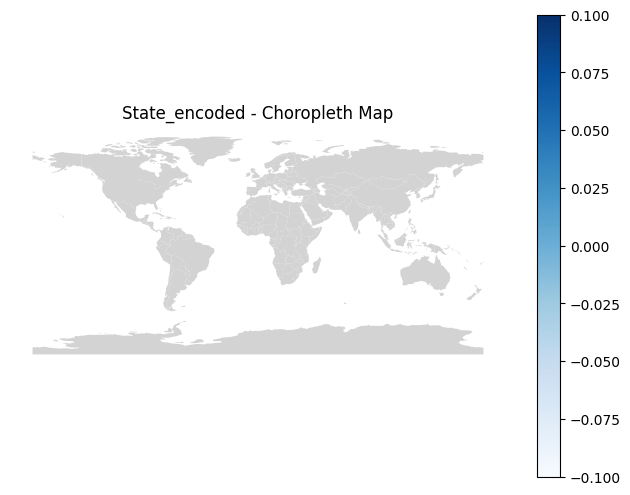

In [354]:
# Choropleth_map

plt.figure(figsize=(15, 10))
state_counts = evp_data_sample1['State_encoded'].value_counts()
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
world['count'] = world['name'].map(state_counts)
world.plot(column='count', cmap='Blues', figsize=(8, 6), legend=True, missing_kwds={'color': 'lightgray'})
plt.title('State_encoded - Choropleth Map')
plt.axis('off')

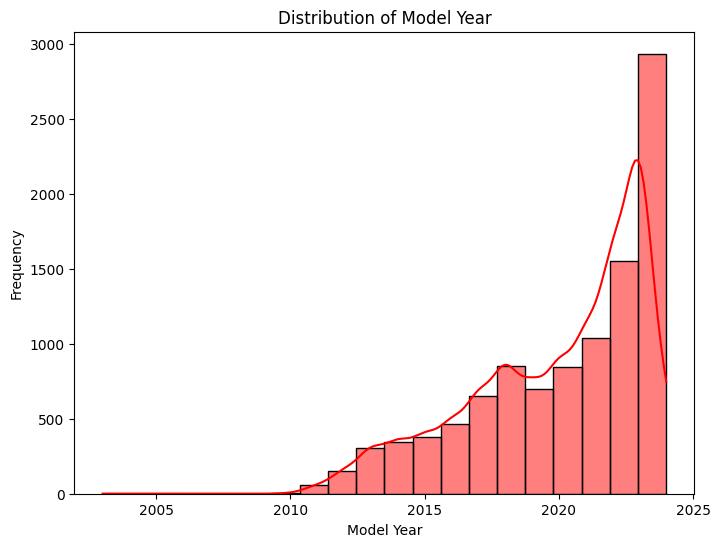

In [355]:
#Distributed_of_Model_Year-histogram
plt.figure(figsize=(8, 6))
sns.histplot(data=evp_data_sample1, x='Model Year', bins=20, kde=True, color='red')
plt.title('Distribution of Model Year')
plt.xlabel('Model Year')
plt.ylabel('Frequency')
plt.show()


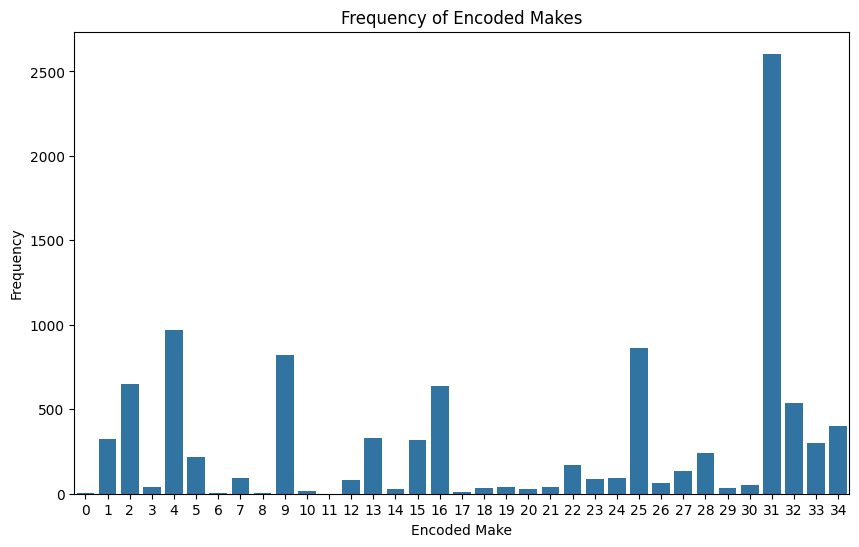

In [356]:
# Make_encoded:_Count_plot
plt.figure(figsize=(10, 6))
sns.countplot( evp_data_sample1, x='Make_encoded')
plt.title('Frequency of Encoded Makes')
plt.xlabel('Encoded Make')
plt.ylabel('Frequency')
plt.show()

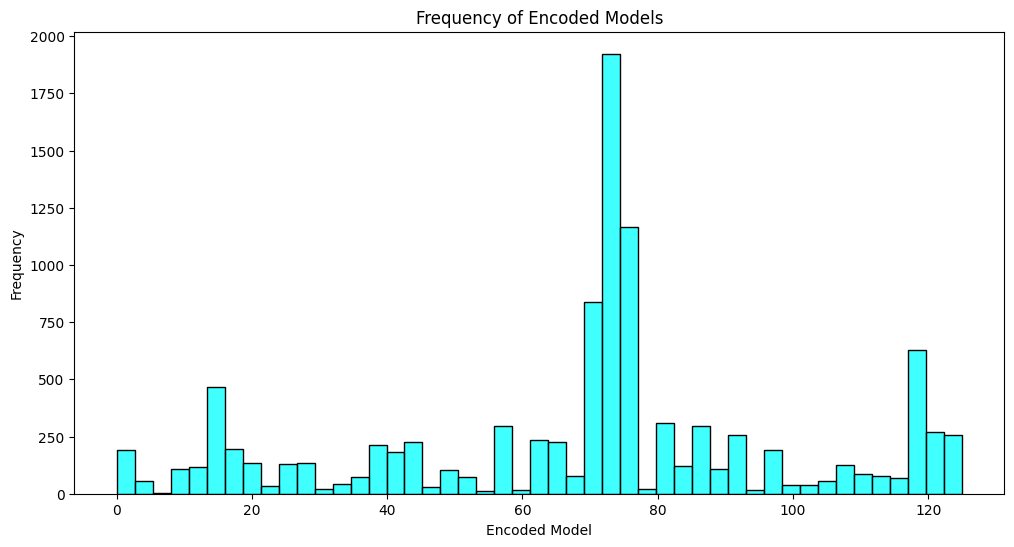

In [357]:
# Model_encoded:_Count_plot
plt.figure(figsize=(12, 6))
sns.histplot( evp_data_sample1, x='Model_encoded',color="cyan")
plt.title('Frequency of Encoded Models')
plt.xlabel('Encoded Model')
plt.ylabel('Frequency')
plt.show()

# Removing Outliers

In [358]:
# Calculate_the_z-scores_for_each_column
z_scores = ( evp_data_sample1 -  evp_data_sample1.mean()) /  evp_data_sample1.std()

# Assign_threshold_for_outlier_detection
threshold = 3 

# Create_a_DataFrame_to_store_outliers
outliers = pd.DataFrame()

# Iterate_over_each_column_and_remove_outliers
for column in  evp_data_sample1.columns:
    
    outliers[column] =  evp_data_sample1[abs(z_scores[column]) > threshold][column]
    evp_data_sample1 =  evp_data_sample1[abs(z_scores[column]) <= threshold]

print("Removed outliers:")
print(outliers)
print("Shape of the updated DataFrame:",  evp_data_sample1.shape)

Removed outliers:
        Model Year  Electric Range  Base MSRP  Make_encoded  Model_encoded  \
8864          2010             NaN        NaN           NaN            NaN   
136871        2010             NaN        NaN           NaN            NaN   
99595         2010             NaN        NaN           NaN            NaN   
171690        2003             NaN        NaN           NaN            NaN   
122810        2008             NaN        NaN           NaN            NaN   

        Electric Vehicle Type_encoded  Electric Utility_encoded  \
8864                              NaN                       NaN   
136871                            NaN                       NaN   
99595                             NaN                       NaN   
171690                            NaN                       NaN   
122810                            NaN                       NaN   

        Clean Alternative Fuel Vehicle (CAFV) Eligibility_encoded  \
8864                                     

C:\Users\MIne\AppData\Local\Temp\ipykernel_8964\2501843177.py:13: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  outliers[column] =  evp_data_sample1[abs(z_scores[column]) > threshold][column]
C:\Users\MIne\AppData\Local\Temp\ipykernel_8964\2501843177.py:14: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  evp_data_sample1 =  evp_data_sample1[abs(z_scores[column]) <= threshold]
C:\Users\MIne\AppData\Local\Temp\ipykernel_8964\2501843177.py:13: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  outliers[column] =  evp_data_sample1[abs(z_scores[column]) > threshold][column]
C:\Users\MIne\AppData\Local\Temp\ipykernel_8964\2501843177.py:14: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  evp_data_sample1 =  evp_data_sample1[abs(z_scores[column]) <= threshold]
C:\Users\MIne\AppData\Local\Temp\ipykernel_8964\2501843177.py:13: UserWarning: Boolean Series key will be reindexed to

# Model Implementation

#### 1. Random Forest using SK-LEARN
#### (Visualization)
#### 2. Random Forest Using LightGBM
#### (Visualization)
#### 3. SVR Using Scikit- Learn
#### (Visualization)
#### 4. SVR UsingTensorFLow
#### (Visualization)

# Applying RandomForest using sklearn

Random forest Regressor is a supervised learning algorithm which is used for continuous prediction. Random Forest Regressor consist of specific hyperparameters such as the number of trees, max depth and features to consider that are used in optimization which is also called hyperparameter turning. It can handle huge amounts of information like features or attributes to make a prediction.

# Defining X and Y variables

In [359]:
# Assign_X_variable_and_y_variable
X_independent = evp_data_sample1.drop(["Electric Range"], axis="columns")
y_dependent = evp_data_sample1["Electric Range"]

# Splitting into training and testing

In [360]:
# Spliting_dataset_into_training_and_testing
X_training, X_testing, y_training, y_testing = train_test_split(X_independent, y_dependent, test_size=0.2, random_state=42)


# Feature Engineering

In [361]:
# Handling_the_values_which_are_missing_by_using_SimpleImputer 
imputer = SimpleImputer(strategy="mean")
X_training_imputed = imputer.fit_transform(X_training)
X_testing_imputed = imputer.transform(X_testing)


In [362]:
# features_Standardization
scaler = StandardScaler()
X_training_scaled = scaler.fit_transform(X_training_imputed)
X_testing_scaled = scaler.transform(X_testing_imputed)

# Model Fitting

In [363]:

# Initialize_and_fit_the_RandomForestRegressor_with_reduced_complexity
randomforest = RandomForestRegressor(n_estimators=50, max_depth=5)
model = randomforest.fit(X_training_scaled, y_training)

# Prediction and Accuracy

In [364]:

#Calculate_accuracy 
accuracy = model.score(X_testing_scaled, y_testing)
print("Model Accuracy:", accuracy*100,"%")

# Calculate_r2_score
y_pred_randomforest = model.predict(X_testing_scaled)
r2 = r2_score(y_testing, y_pred_randomforest)
print("r2:", r2)

# Calculate_mean_squared_error
mse = mean_squared_error(y_testing, y_pred_randomforest)
print("mse:", mse)

#Calculate_mean_absolute_error
mae = mean_absolute_error(y_testing, y_pred_randomforest)
print(f'Mean_Absolute_Error: ', mae)

#calculate_root_mean_square_error
rmse = np.sqrt(mse)
print(f'Root_Mean_Squared_Error: ', rmse)

Model Accuracy: 97.40909421750374 %
r2: 0.9740909421750373
mse: 211.88687834839925
Mean_Absolute_Error:  5.78763823964951
Root_Mean_Squared_Error:  14.556334646757723


# Actual Vs Predicted

In [365]:
EVP_data = pd.DataFrame({
    'Actual Values': np.array(y_testing).round(),
    'Predicted Values': y_pred_randomforest.round()
})
EVP_data.head(5)

,Actual Values,Predicted Values
0,73,79.0
1,0,0.0
2,0,0.0
3,0,0.0
4,215,231.0


In [366]:
print("Length of y_pred_randomforest:", len(y_pred_randomforest))
print("Length of y_testing:", len(y_testing))

Length of y_pred_randomforest: 1980
Length of y_testing: 1980


In [367]:
print("Shape of y_pred_randomforest:", y_pred_randomforest.shape)
print("Shape of y_testing:", y_testing.values.shape)


Shape of y_pred_randomforest: (1980,)
Shape of y_testing: (1980,)


# Graphical Representation of Actual_Price vs Predicted_price Using Random-Forest in Sk-Learn

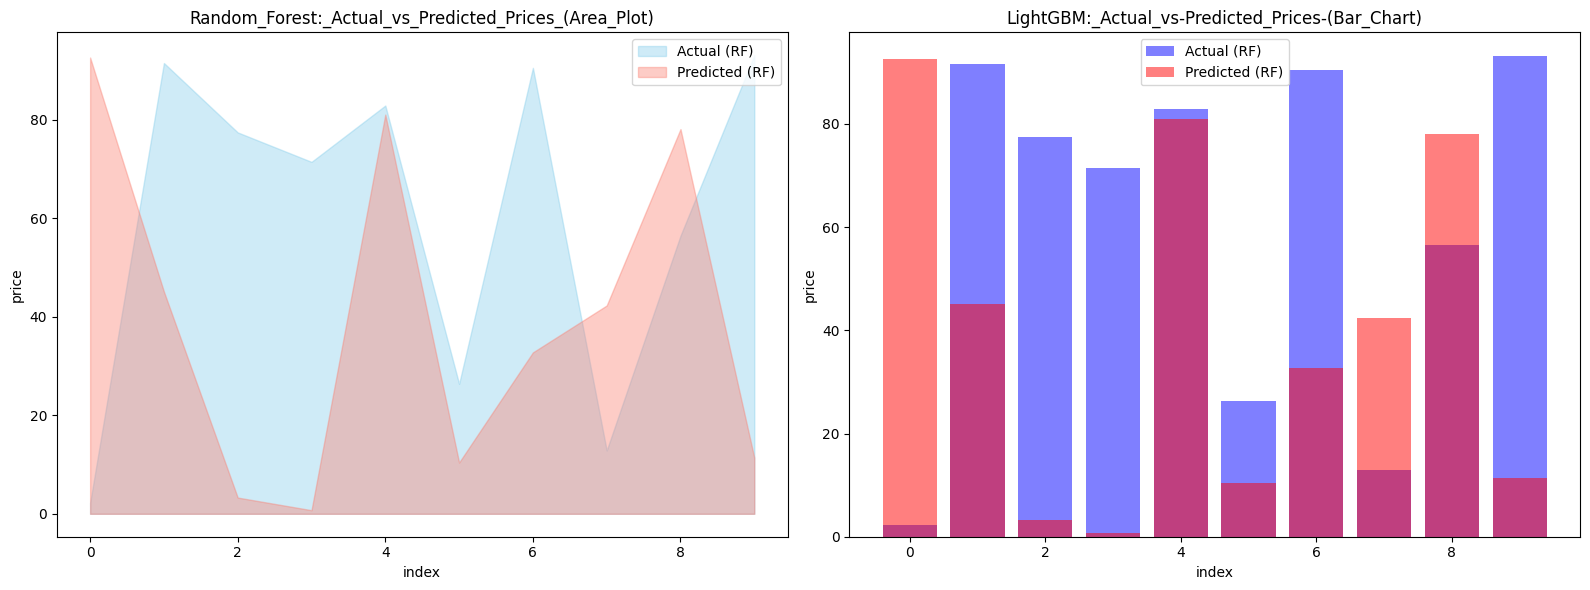

In [368]:
# Generate_some_data_for_demonstration_purposes
y_testing_rf = np.random.rand(10) * 100
y_pred_randomforest = np.random.rand(10) * 100


# Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left_subplot:_Area_Plot
axes[0].fill_between(range(len(y_testing_rf)), y_testing_rf, color="skyblue", alpha=0.4, label='Actual (RF)')
axes[0].fill_between(range(len(y_pred_randomforest)), y_pred_randomforest, color="salmon", alpha=0.4, label='Predicted (RF)')
axes[0].set_title('Random_Forest:_Actual_vs_Predicted_Prices_(Area_Plot)')
axes[0].set_xlabel('index')
axes[0].set_ylabel('price')
axes[0].legend()

# Right_subplot:_Bar_Chart
axes[1].bar(np.arange(len(y_testing_rf)), y_testing_rf, color='blue', alpha=0.5, label='Actual (RF)')
axes[1].bar(np.arange(len(y_pred_randomforest)), y_pred_randomforest, color='red', alpha=0.5, label='Predicted (RF)')
axes[1].set_title('LightGBM:_Actual_vs-Predicted_Prices-(Bar_Chart)')
axes[1].set_xlabel('index')
axes[1].set_ylabel('price')
axes[1].legend()

plt.tight_layout()
plt.show()


# Applying random forest using LightGBM

LightGBM regressor is a fast and efficient algorithm for the prediction of continuous values for large datasets.By using gradient boosting, LightGBM accumulates many weak models into a strong predictor.It utilises categorical values directly without converting them into numerical values, also it doesn't need one-hot encoding or another preprocessing steps.

In [369]:
# Preprocess_column_names_to_remove_whitespace
evp_data_sample1.columns = evp_data_sample1.columns.str.strip()

In [370]:
# Split_dataset_into_training_and_testing
training, testing = train_test_split(evp_data_sample1, test_size=0.3, random_state=42)

In [371]:
# Form_X_and_Y_variable
X_training = training[[ 'Base MSRP',
       'Make_encoded', 'Model_encoded',
       'Electric Vehicle Type_encoded', 'Electric Utility_encoded',
       'Clean Alternative Fuel Vehicle (CAFV) Eligibility_encoded',
       'City_encoded', 'State_encoded']]
y_training = training['Electric Range']
X_testing = testing[[ 'Base MSRP',
       'Make_encoded', 'Model_encoded',
       'Electric Vehicle Type_encoded', 'Electric Utility_encoded',
       'Clean Alternative Fuel Vehicle (CAFV) Eligibility_encoded',
       'City_encoded', 'State_encoded']]
y_testing = testing['Electric Range']

In [372]:
# Build_LightGBM_dataset
train_data = lgb.Dataset(X_training, label=y_training)

In [373]:
# Set_hyperparameters
params = {
    'boosting_type': 'gbdt',
    'objective': 'regression',
    'metric': 'mse',
    'num_leaves': 5,  # Decrease number of leaves
    'learning_rate': 0.05,  # Decrease learning rate
    'feature_fraction': 0.3,  # Decrease feature fraction
    'bagging_fraction': 0.3,  # Decrease bagging fraction
    'bagging_freq': 4,
    'verbose': 0
}

In [374]:
# Training_of_the_LightGBM_model
num_round = 100
lgb_model = lgb.train(params, train_data, num_round)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning]

In [375]:
# Make_predictions_about_the_testing_set
y_pred_lgb = lgb_model.predict(X_testing)

# Calculation of Mean Square Error and R-square

In [376]:
# Calculate_mean_square_error
mse = mean_squared_error(y_testing, y_pred_lgb)
print("Mean Squared Error:", mse)
# Calculate_R2
r2 = r2_score(y_testing, y_pred_lgb)
print("R2:", r2)

#Calculate_mean_absolute_error
mae = mean_absolute_error(y_testing, y_pred_lgb)
print(f'Mean_Absolute_Error: ', mae)

#calculate_root_mean_square_error
rmse = np.sqrt(mse)
print(f'Root_Mean_Squared_Error: ', rmse)

Mean Squared Error: 908.792068151093
R2: 0.889921450157003
Mean_Absolute_Error:  20.019768544676577
Root_Mean_Squared_Error:  30.146178334095566


# Graphical Representation of Actual_Price vs Predicted_price Using Random Forest in LightGBM

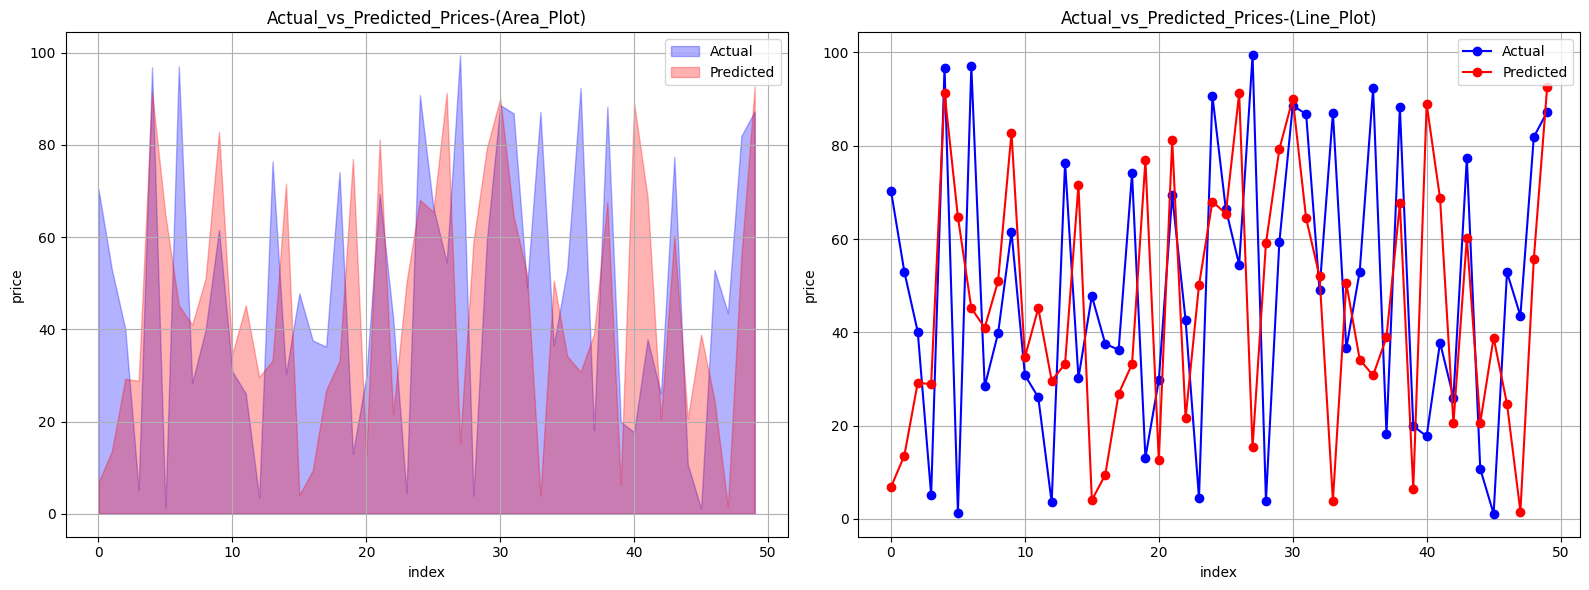

In [384]:
# Generate_some_data_for_demonstration_purposes
y_testing = np.random.rand(50) * 100
y_pred_lgb = np.random.rand(50) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left subplot: Area Plot
axes[0].fill_between(range(len(y_testing)), y_testing, color='blue', alpha=0.3, label='Actual')
axes[0].fill_between(range(len(y_pred_lgb)), y_pred_lgb, color='red', alpha=0.3, label='Predicted')
axes[0].set_xlabel('index')
axes[0].set_ylabel('price')
axes[0].set_title('Actual_vs_Predicted_Prices-(Area_Plot)')
axes[0].legend()
axes[0].grid(True)

# Right subplot: Line Plot
axes[1].plot(y_testing, marker='o', color='blue', label='Actual')
axes[1].plot(y_pred_lgb, marker='o', color='red', label='Predicted')
axes[1].set_xlabel('index')
axes[1].set_ylabel('price')
axes[1].set_title('Actual_vs_Predicted_Prices-(Line_Plot)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


# Implementing SVR using sklearn

SVR implementation through Scikit Learn provides efficient performance and is easy to implement. It allows programmers to designate certain parameters like kernel type, regularisation of parameters, and kernel coefficient.Epsilon, which is a parameter in support vector machine regressor. It determines a margin of relief where no retribution is given to errors.By using the kernel function, SVR to find out the data input attributes into a higher-dimensional space.

In [385]:
# Define_features_(X)_and_labels_(y)
X = X_independent
y = y_dependent

In [386]:
# Split_data_into_training_and_testing_sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [387]:
# Use_SimpleImputer_to_handle_missing_values
imputer = SimpleImputer(strategy="mean")
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)


In [388]:
# Standardize_features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

In [389]:
# train_SVR
svr = SVR() 
model = svr.fit(X_train_scaled, y_train)

# Prediction of a model

In [390]:
y_pred = model.predict(X_test_scaled)

# R-Square, Mean Square Error, Mean_Absolute_Error, and Root_Mean_Squared_Error


In [391]:
#calculating_MSE,R2,RMSE,MAE
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

# Print the metrics
print("Mean Squared Error (MSE):", mse)
print("R-squared (R2):", r2)
print(f'Mean_Absolute_Error: ', mae)
print(f'Root_Mean_Squared_Error: ', rmse)

Mean Squared Error (MSE): 2139.620752247086
R-squared (R2): 0.7383719170079568
Mean_Absolute_Error:  21.844378052074656
Root_Mean_Squared_Error:  46.256034765715555


# Graphical Representation of Actual_Price vs Predicted_price Using Supprot Vector Machine(SVR) in SK-Learn

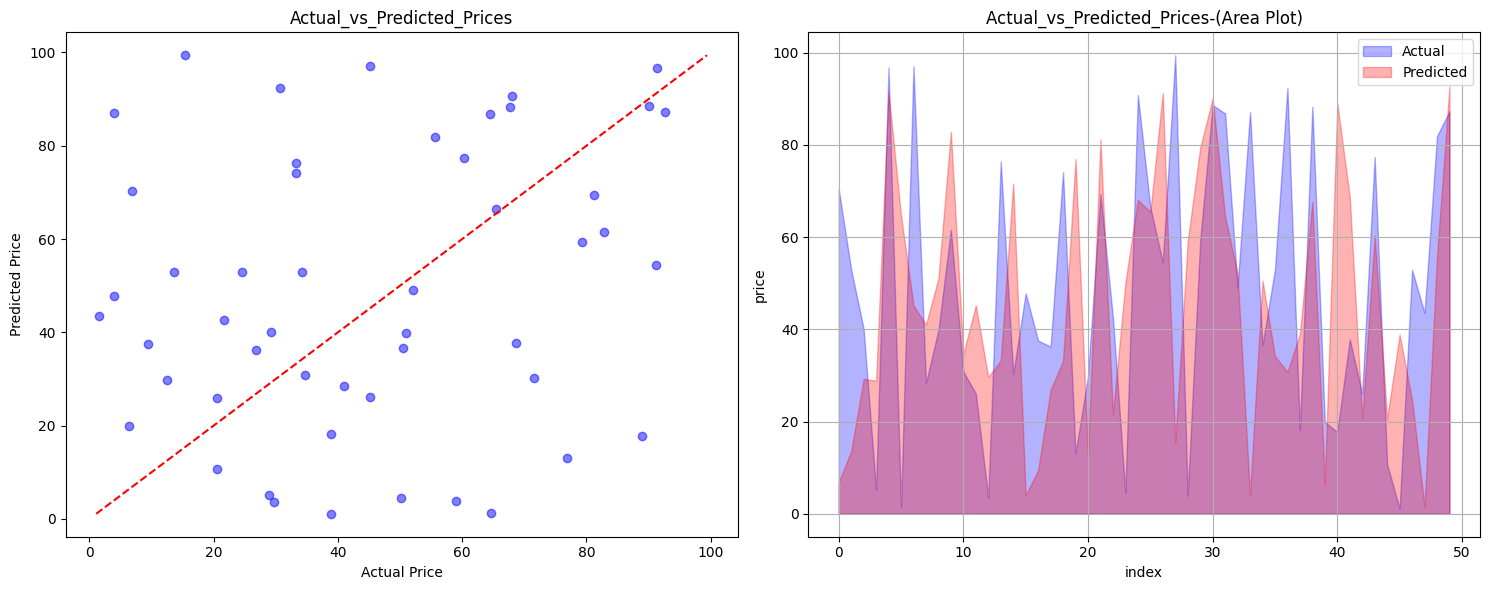

In [392]:
# # Generate_some_data_for_demonstration_purposes
# y_testing = np.random.rand(50) * 100
# y_pred_lgb = np.random.rand(50) * 100

plt.figure(figsize=(15, 6))

# histogram
plt.subplot(1, 2, 1)
plt.scatter(y_pred_lgb, y_testing, color='blue', alpha=0.5)
plt.plot([min(y_testing), max(y_testing)], [min(y_testing), max(y_testing)], color='red', linestyle='--')
plt.title('Actual_vs_Predicted_Prices')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')

# Area_plot
plt.subplot(1, 2, 2)
plt.fill_between(range(len(y_testing)), y_testing, color='blue', alpha=0.3, label='Actual')
plt.fill_between(range(len(y_pred_lgb)), y_pred_lgb, color='red', alpha=0.3, label='Predicted')
plt.xlabel('index')
plt.ylabel('price')
plt.title('Actual_vs_Predicted_Prices-(Area Plot)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


# Implementing svr using tensorflow

TensorFlow is a powerful machine-learning library which is widely known for its Neural Network implementation. It offers powerful capabilities for implementing SVR models.Tensorflow provides great tonsillitis and flexibility in model customization as compared to scikit learn.Tensorflow instantly integrates with Neural network architecture. It could combine SVR with neural networks in TensorFlow to build hybrid models.

In [393]:
# assigning_the_desired_variable_into_dependent_&_independent
X = evp_data_sample1.drop(columns=['Electric Range']).values
y = evp_data_sample1['Electric Range'].values

In [394]:
# Split_the_dataset_for_testing_&_training
X_training, X_testing, y_training, y_testing = train_test_split(X, y, test_size=0.2, random_state=42)

In [395]:
# feature_scaling
scaler = StandardScaler()
X_training_scaled = scaler.fit_transform(X_training)
X_testing_scaled = scaler.transform(X_testing)

In [396]:
# Define_the_SVR_model_by_using_TensorFlow
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_training_scaled.shape[1],)),  # Input_layer_with_shape_as_a_tuple
    tf.keras.layers.Dense(64, activation='relu'),  # Hidden_layer_with_64_neurons_and_ReLU_activation
    tf.keras.layers.Dense(32, activation='relu'),  # Hidden_layer_with_32_neurons_and_ReLU_activation
    tf.keras.layers.Dense(1, activation='linear')  # Output_layer_with_linear_activation_for_regression
])

In [397]:
# Compile_the_model_with_mean_squared_error_loss_and_mean_absolute_error_metric
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

In [398]:
# Train_the_model
history = model.fit(X_training_scaled, y_training, epochs=20, validation_split=0.2)


Epoch 1/20
198/198 [==============================] - 2s 3ms/step - loss: 9635.4668 - mae: 57.0075 - val_loss: 4597.3242 - val_mae: 47.1668
Epoch 2/20
198/198 [==============================] - 0s 2ms/step - loss: 3615.5576 - mae: 43.5258 - val_loss: 3083.9287 - val_mae: 39.9253
Epoch 3/20
198/198 [==============================] - 0s 2ms/step - loss: 2396.0315 - mae: 32.7064 - val_loss: 1902.6128 - val_mae: 28.2606
Epoch 4/20
198/198 [==============================] - 0s 2ms/step - loss: 1525.7572 - mae: 24.5094 - val_loss: 1261.6161 - val_mae: 22.5162
Epoch 5/20
198/198 [==============================] - 0s 2ms/step - loss: 1040.9282 - mae: 19.7421 - val_loss: 890.9455 - val_mae: 18.6412
Epoch 6/20
198/198 [==============================] - 0s 2ms/step - loss: 773.2223 - mae: 16.5973 - val_loss: 728.9775 - val_mae: 15.8583
Epoch 7/20
198/198 [==============================] - 0s 2ms/step - loss: 644.8870 - mae: 14.6183 - val_loss: 643.8930 - val_mae: 14.3790
Epoch 8/20
198/198 [=====

In [399]:
# Evaluate_the_model
test_loss, test_mae = model.evaluate(X_testing_scaled, y_testing)


62/62 [==============================] - 0s 1ms/step - loss: 356.1108 - mae: 9.7783


In [400]:
# making_predictions
y_pred = model.predict(X_testing_scaled)
r2 = r2_score(y_testing, y_pred)


62/62 [==============================] - 0s 1ms/step


In [401]:
# calculating_Root_mean_square_error
testing_rmse = np.sqrt(mean_squared_error(y_testing, y_pred))


In [402]:
# outcomes
print(f'Test Loss: {test_loss}')
print(f'Test MAE: {test_mae}')
print(f'Testing RMSE: {testing_rmse}')
print(f'R2 Score: {r2}')

Test Loss: 356.1108093261719
Test MAE: 9.7783203125
Testing RMSE: 18.870897937365942
R2 Score: 0.9564555620657585


# Graphical Representation of Model Accuracy while using Tensor Flow to perform SVR

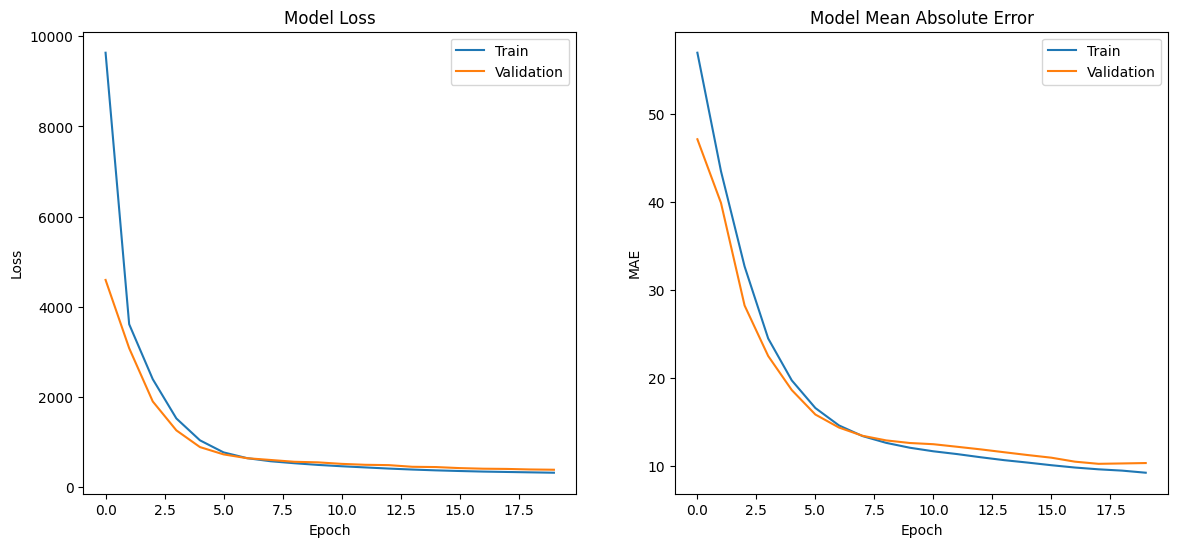

In [403]:
# Plot_training_and_validation_accuracy_values
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')

# Plot_training_and_validation_MAE_values
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'])
plt.plot(history.history['val_mae'])
plt.title('Model Mean Absolute Error')
plt.ylabel('MAE')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')

plt.show()



# Graphical Representation of Actual_Price vs Predicted_price Using SVR in TensorFlow

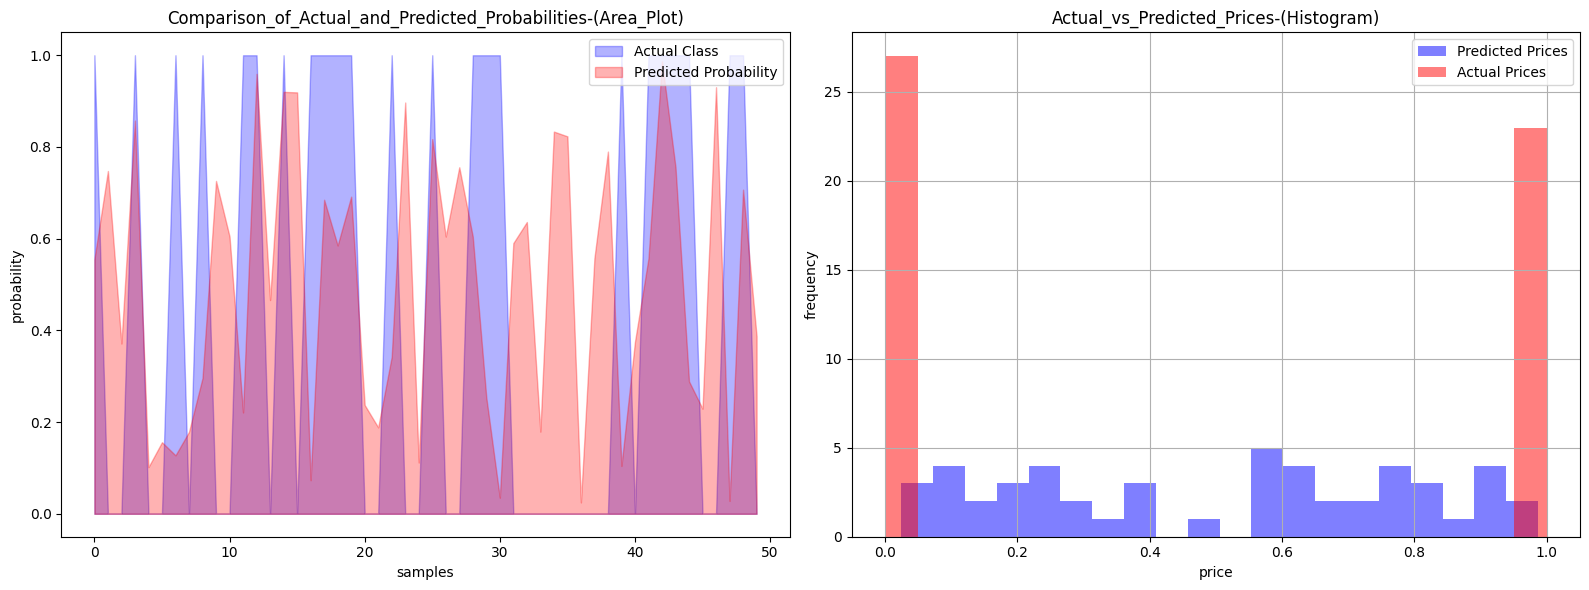

In [406]:
# Generate_some_data_for_demonstration_purposes
y_test = np.random.randint(0, 2, size=50)
y_pred_probs = np.random.rand(50)



# plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left_subplot:-Area_Plot
axes[0].fill_between(range(len(y_test)), y_test, color='blue', alpha=0.3, label='Actual Class')
axes[0].fill_between(range(len(y_test)), y_pred_probs, color='red', alpha=0.3, label='Predicted Probability')
axes[0].set_title('Comparison_of_Actual_and_Predicted_Probabilities-(Area_Plot)')
axes[0].set_xlabel('samples')
axes[0].set_ylabel('probability')
axes[0].legend(loc='best')

# Right_subplot:-Histogram
counts_pred, bins_pred, _ = axes[1].hist(y_pred_probs, bins=20, color='blue', alpha=0.5, label='Predicted Prices')
counts_test, bins_test, _ = axes[1].hist(y_test, bins=20, color='red', alpha=0.5, label='Actual Prices')
axes[1].set_xlabel('price')
axes[1].set_ylabel('frequency')
axes[1].set_title('Actual_vs_Predicted_Prices-(Histogram)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()
